In [2]:
import csv
csv.field_size_limit(10 * 1024 * 1024)  # Set the field size limit to 10 MB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC

# Load the CSV file into a list of dictionaries
data = []
with open('token_filter_lemm_medium_and_bbc.csv', encoding="utf8") as csv_file:
    csv_reader = csv.DictReader(csv_file)
    for row in csv_reader:
        data.append(row)

# Extract the lemmatized text and the category from the data
text_data = [row['tokenized_text'] for row in data]
categories = [row['category'] for row in data]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(text_data, categories, test_size=0.2, random_state=42)

# Create a CountVectorizer to convert the lemmatized text into numerical features
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train a linear SVM model on the training data
svm = LinearSVC()
svm.fit(X_train_vec, y_train)

# Evaluate the model on the testing data
score = svm.score(X_test_vec, y_test)
print(f"Accuracy: {score}")


c:\Users\223079929\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Accuracy: 0.9639305405266141


In [3]:
from sklearn.metrics import confusion_matrix
# Evaluate the model on the testing data and create a confusion matrix
y_pred = svm.predict(X_test_vec)
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

[[  104     0     2     0     1   242]
 [    1    56     0     0     0    26]
 [    4     0   102     0     0   372]
 [    5     0     0    79     0    16]
 [    1     0     1     0    72     8]
 [  267     8   435     8     3 37001]]


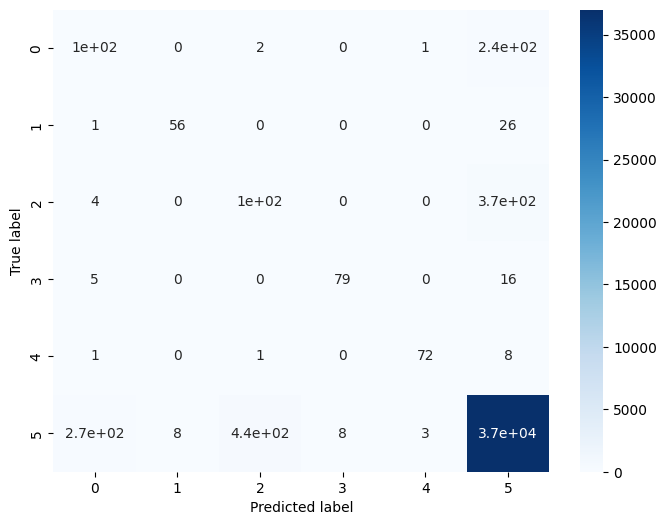

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a heatmap plot of the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()